In [2]:
from probjax.nn.layers.attention import flex_attention, dot_product_attention, BlockSizes
from probjax.nn.nets import Transformer
from probjax.utils.bmutil import benchmark
import jax.numpy as jnp
import jax

from flax import nnx
from functools import partial
from probjax.utils.bmutil import benchmark

from probjax.nn.pallas_kernels.flash_attention import flash_attention, build_mask


In [24]:
import functools
from dataclasses import dataclass, field
from typing import Optional, final, Union, Type, Sequence

Tensor = jax.Array

@functools.partial(dataclass, eq=False)
class BaseAttentionBias:
    """Base class representing attention logit biases."""

    # The dtype of the biases to return in `value()`.
    # If None, do not cast the dtype.
    dtype: Optional[jnp.dtype] = field(kw_only=True, default=None)

    @final
    def eval_shape(self) -> tuple[int, int, int, int]:
        """Return the shape of the bias tensor.

        Note: this doesn't materialize the value. jax.eval_shape calls value(), but it only does so
        using tracers.

        Returns
            shape: [batch or 1, num_heads or 1, target_len, source_len].

        Raises:
            ValueError: If the bias has no value.
        """
        if not self.has_value():
            raise ValueError("AttentionBias has no value.")
        return jax.eval_shape(type(self).value, self).shape

    @final
    def has_value(self) -> bool:
        """Return whether to the bias has a value."""
        return jax.eval_shape(type(self).value, self) is not None

    @final
    def value(self) -> Optional[Tensor]:
        """Return a tensor with the biases or None if there are no biases.

        Shape: [batch or 1, num_heads or 1, target_len, source_len].

        The dtype will be cast to `self.dtype` if it is not None.
        """
        value = self._value()
        if self.dtype is not None and value is not None:
            value = value.astype(self.dtype)
        return self._broadcast_value(value)

    def _value(self) -> Optional[Tensor]:
        """Internal version of `value()` without the casting and broadcasting done in the public
        method.

        Subclasses must implement this.

        Shape: Any of:
        * [target_len, source_len]
        * [batch or 1, target_len, source_len]
        * [batch or 1, num_heads or 1, target_len, source_len].
        """
        raise NotImplementedError

    def __add__(self, other: "BaseAttentionBias") -> "CompositeAttentionBias":
        """Returns a bias tensor representing the sum of `self` and `other`.

        The implementation lazily adds them by creating a CompositeAttentionBias
        from the biases being added.
        """
        return CompositeAttentionBias([self, other])

    def astype(self, dtype: jnp.dtype) -> "BaseAttentionBias":
        """Return a new bias whose dtype is `dtype`."""
        result = dataclasses.replace(self, dtype=dtype)
        result = cast(BaseAttentionBias, result)
        return result

    @classmethod
    def _broadcast_value(cls, value: Tensor) -> Tensor:
        """Broadcasts `value` to a canonical 4 dimensional attention bias shape.

        Raises:
            ValueError: If the shape of `value` is not 2, 3, or 4 dimensional.
        """
        if value is None or value.ndim == 4:
            return value
        if value.ndim == 2:
            # Shape: [1, 1, target_length, source_length].
            return value[None, None, :, :]
        elif value.ndim == 3:
            # Shape: [batch, 1, target_length, source_length].
            return value[:, None, :, :]
        raise ValueError(f"Invalid attention_logit_biases shape: {value.shape}.")

    def partition_spec(
        self, mha_dim_to_partition_spec: dict[str]
    ) -> Union["BaseAttentionBias"]:
        """Compute a partition spec for this bias."""
        raise NotImplementedError

    def bias_and_residual(self, cls) -> "BiasAndResidual[B]":
        """Split this bias into a bias of type `cls` and a residual.

        If the two returned biases are added together, the result is equivalent to
        the value of this bias.

        The default implementation returns `self` as either the bias or residual.
        Which field is set to `self` is based on whether this is an instance of `cls`.
        If it is an instance, `self` is returned in the bias field and the `residual` field will be
        a `BaseAttentionBias` with value() None.
        If not, it is returned in the `residual` field, and the `bias` field is set to `None`.
        """
        if isinstance(self, cls):
            return BiasAndResidual(bias=self, residual=CompositeAttentionBias([]))
        return BiasAndResidual(bias=None, residual=self)

    @classmethod
    def from_sequence(cls, biases: Sequence["BaseAttentionBias"]) -> Optional["BaseAttentionBias"]:
        """Constructs a single combined attention bias of the same type as this class
        from a sequence of such biases.

        If the sequence is empty, returns None.

        The default implementation returns the bias if the sequence has length one and
        raises for length > 1.

        Raises:
            NotImplementedError: If the sequence has length > 1.
            TypeError: If `seq` contains a type of bias that is not an instance of this class.
            ValueError: If `eval_shape()` is not the same for every bias.
        """

        if not biases:
            return None

        shape = biases[0].eval_shape()
        for bias in biases:
            if not isinstance(bias, cls):
                raise TypeError(f"Got bias type {type(bias)}, not instance of {cls}.")
            if bias.eval_shape() != shape:
                raise ValueError(f"Got shape mismatch {bias.eval_shape()} != {shape}.")

        if len(biases) == 1:
            return biases[0]
        raise NotImplementedError


BaseAttentionBias

__main__.BaseAttentionBias

In [2]:
import jax
import jax.numpy as jnp
seq_len = 2048
q = jax.random.normal(jax.random.PRNGKey(0), (1,seq_len, 16, 64), dtype=jnp.bfloat16)
k = jax.random.normal(jax.random.PRNGKey(1), (1,seq_len, 16, 64), dtype=jnp.bfloat16)
v = jax.random.normal(jax.random.PRNGKey(2), (1,seq_len, 16, 64), dtype=jnp.bfloat16)



In [3]:
attn_fn = jax.jit(dot_product_attention)

In [4]:
_ = benchmark(attn_fn, q, k, v)

GPU Utilization: 85% +/- 15%,GPU Memory Utilization: 85% +/- 15% 
CPU Utilization: 0% +/- 0%
Memory Utilization: 0% +/- 0%
Average time taken: 750.13 us


In [11]:
attn_fn = jax.jit(partial(flex_attention, num_stages=2, mask_mod_fn = lambda q_id, k_id, x,y,l,m: jnp.abs(q_id - k_id) <= 32, block_sizes=BlockSizes(32, 32) ))

In [12]:
from functools import partial


_ = benchmark(attn_fn, q, k, v)

GPU Utilization: 81% +/- 13%,GPU Memory Utilization: 0% +/- 0% 
CPU Utilization: 0% +/- 0%
Memory Utilization: 0% +/- 0%
Average time taken: 487.35 us


In [13]:
attn_fn = jax.jit(partial(flex_attention, num_stages=2,  mask_mod_fn = lambda start_q, start_k, l,f,span_q,span_k: jnp.abs(l[None,:] -f[:,None]) <= 32, block_sizes=BlockSizes(32, 32) ))
out = attn_fn(q, k, v)

In [24]:
attn_fn = jax.jit(dot_product_attention)
out3 = attn_fn(q, k, v)

In [31]:
attn_fn = jax.jit(partial(flex_attention, sm_scale=1.))
out = attn_fn(q, k, v)

In [14]:
attn_fn = jax.jit(partial(flash_attention, mask_fn=lambda q_id, k_id: jnp.abs(q_id - k_id) <= 32, block_q=32, block_k=32))

In [32]:
attn_fn = jax.jit(flash_attention)
out2 = attn_fn(q, k, v)

In [15]:
out2 = attn_fn(q, k, v)

In [33]:
out - out2

Array([[[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0.000976562, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        ...,

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0.000244141, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0,

In [11]:
_ = benchmark(attn_fn, q, k, v)

GPU Utilization: 40% +/- 7%,GPU Memory Utilization: 0% +/- 0% 
CPU Utilization: 2% +/- 1%
Memory Utilization: 0% +/- 0%
Average time taken: 77.48 us


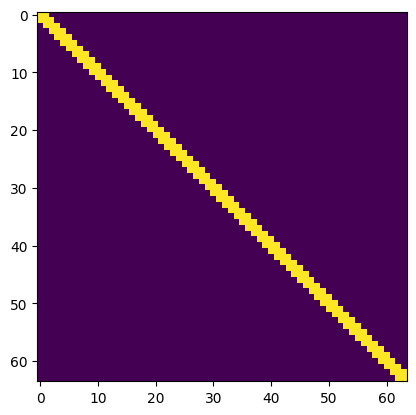

In [12]:
import matplotlib.pyplot as plt
plt.imshow(build_mask(lambda q_id, k_id: jnp.abs(q_id - k_id) < 32, q_seq_len=2048,kv_seq_len=2048, block_q=32, block_k=32))

In [13]:
from probjax.nn.pallas_kernels.flash_attention import query_iterator_indices
blockmask = build_mask(lambda q_id, k_id: jnp.abs(q_id - k_id) < 2, q_seq_len=2048,kv_seq_len=2048, block_q=64, block_k=64)
q_id, k_id = query_iterator_indices(blockmask)

In [14]:

blockmask[0]

array([ True,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False])

In [15]:
q_id[9]

Array([ 8,  9, 10,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],      dtype=int32)

In [16]:
k_id

Array([2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 2], dtype=int32)

In [17]:
attn_fn = jax.jit(partial(flex_attention, num_stages=3, window_size=(-32,32)))

In [18]:
attn_fn = jax.jit(flex_attention)

In [19]:
attn_fn = jax.jit(partial(flash_attention, mask_fn=lambda q_id, k_id: jnp.abs(q_id - k_id) <= 32, block_q=64, block_k=64))
#attn_fn = jax.jit(flash_attention)

In [20]:
def f(q):
    q = q.repeat(16, axis=-2)
    q = q.repeat(64, axis=-1)
    return attn_fn(q,q,q).sum(axis=(-2,-1))


f_grad_jit = jax.jit(jax.grad(f))

In [21]:
J = jax.jacobian(f)(q[:,:128,:1, :1])

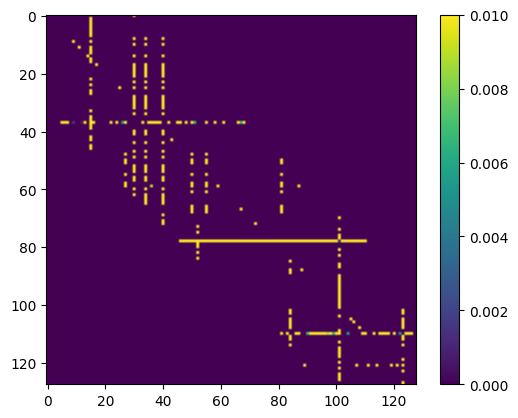

In [22]:
plt.imshow(J.reshape((128,128)),vmin=0,vmax=.01)
plt.colorbar()

In [23]:
%%timeit 
f_grad_jit(q).block_until_ready()

TypeError: Gradient only defined for scalar-output functions. Output had shape: (1, 2048).

In [ ]:
def f(q):
    return attn_fn(q,q.repeat(2, axis=1),q.repeat(2, axis=1)).sum()


f_grad_jit = jax.jit(jax.grad(f))

In [ ]:
%%timeit 
f_grad_jit(q).block_until_ready()

6.58 ms ± 21.1 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
